In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sub_experiments = ['background', 'target', 'target_polarity']

path = '../../results/remote/'

data = pd.DataFrame()

for test in sub_experiments:
    
    df = pd.read_csv(f'{path}results_{test}/movement_rate_metrics.csv')
    df['study'] = test
    data = pd.concat([data, df])
    data = data.reset_index(drop = True)
    
data['study_condition'] = [f'{data.condition[idx]}_{data.study[idx]}' for idx in data.index]
data['abs_magnitude'] = np.abs(data.magnitude)

In [3]:
def make_metric_for_all_studies_plot(data, x_axis, metric, 
                                     facecolors, edgecolors, barcolors, 
                                     studies, conditions, figsize, save_path,
                                     show_null = False):
    fig, axs = plt.subplots(1, 1, figsize = figsize)
    if show_null:
        axs.hlines(0, 0, 13, color = 'grey', zorder = -3)
    pos = 0
    for study in studies:
        study_data = data[data.study == study]
        for condition in conditions:
            a = sns.stripplot(data=study_data[study_data.condition.isin([condition])],
                    x = pos,
                    y = metric,
                    hue = x_axis,
                    palette = facecolors,
                    linewidth = 1,
                    edgecolor = edgecolors[f'{condition}_{study}'],
                    legend = False,
                    ax = axs,
                    alpha = 0.5,
                    zorder = -2)

            axs.vlines(pos, 
                       study_data[study_data.condition.isin([condition])][metric].mean()-study_data[study_data.condition.isin([condition])][metric].sem(),
                       study_data[study_data.condition.isin([condition])][metric].mean()+study_data[study_data.condition.isin([condition])][metric].sem(),
                       color = barcolors[f'{condition}_{study}'], zorder = -1)

            axs.scatter(pos, study_data[study_data.condition.isin([condition])][metric].mean(),
                        facecolor = facecolors[f'{condition}_{study}'], 
                        edgecolor = edgecolors[f'{condition}_{study}'], 
                        s = 20,
                       linewidth = 2,
                       zorder = 1)

            pos+=1
        a = sns.stripplot(data=study_data[study_data.condition.isin([condition])],
                    x = pos,
                    y = metric,
                    legend = False,
                    ax = axs,
                    alpha = 0,
                    zorder = -2)

        pos+=1

    plt.xticks([]);
    plt.savefig(save_path)
    plt.show()

In [4]:
barcolors = {'flash+ jump+_background': '#3DA7B8',
              'flash+ jump+_target': '#C73E1D',
              'flash+ jump+_target_polarity': '#FFC759', 
              'flash+ jump-_background': '#3DA7B8',
              'flash+ jump-_target':'#C73E1D', 
              'flash+ jump-_target_polarity': '#FFC759',
              'flash- jump+_background': 'black', 
              'flash- jump+_target': 'black',
              'flash- jump+_target_polarity': 'black', 
              'flash- jump-_background': 'black',
              'flash- jump-_target': 'black', 
              'flash- jump-_target_polarity':'black' 
}

facecolors = {'flash+ jump+_background': '#3DA7B8',
              'flash+ jump+_target': '#C73E1D',
              'flash+ jump+_target_polarity': '#FFC759', 
              'flash+ jump-_background': 'white',
              'flash+ jump-_target':'white', 
              'flash+ jump-_target_polarity': 'white',
              'flash- jump+_background': 'black', 
              'flash- jump+_target': 'black',
              'flash- jump+_target_polarity': 'black', 
              'flash- jump-_background': 'white',
              'flash- jump-_target': 'white', 
              'flash- jump-_target_polarity':'white' 
}

edgecolors = {'flash+ jump+_background': None,
              'flash+ jump+_target': None,
              'flash+ jump+_target_polarity': None, 
              'flash+ jump-_background': '#3DA7B8',
              'flash+ jump-_target':'#C73E1D', 
              'flash+ jump-_target_polarity': '#FFC759',
              'flash- jump+_background': None, 
              'flash- jump+_target': None,
              'flash- jump+_target_polarity': None, 
              'flash- jump-_background': 'black',
              'flash- jump-_target': 'black', 
              'flash- jump-_target_polarity':'black' 
}

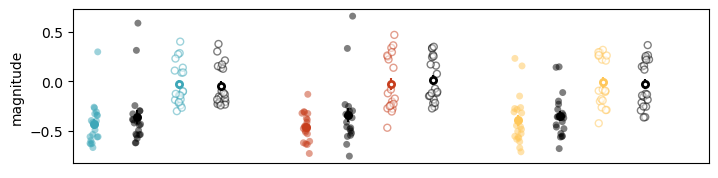

In [5]:
metric = 'magnitude'
studies = sub_experiments
conditions = ['flash+ jump+', 'flash- jump+', 'flash+ jump-', 'flash- jump-']
save_path = '../../results/all_magnitudes_combined.svg'
x_axis = 'study_condition'
figsize = (8.2, 2)


make_metric_for_all_studies_plot(data, x_axis, metric, 
                                 facecolors, edgecolors, barcolors, 
                                 studies, conditions, 
                                 figsize, save_path, show_null = False)

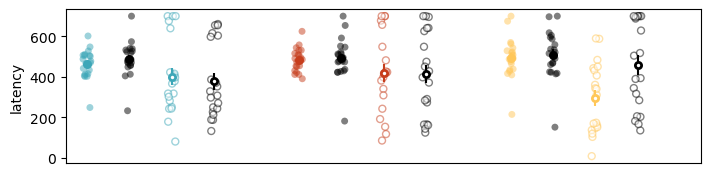

In [6]:
metric = 'latency'
save_path = '../../results/all_latencies_combined.svg'

make_metric_for_all_studies_plot(data, x_axis, metric, 
                                 facecolors, edgecolors, barcolors, 
                                 studies, conditions, 
                                 figsize, save_path)

In [7]:
data

,condition,minimum,latency,baseline,magnitude,flash_shown,stim_jumped,prolific_id,study,study_condition,abs_magnitude
0,flash+ jump+,0.374969,434,1.0,-0.625031,1,1,5ae0b548e0feeb0001cafc45,background,flash+ jump+_background,0.625031
1,flash+ jump-,0.700097,367,1.0,-0.299903,1,0,5ae0b548e0feeb0001cafc45,background,flash+ jump-_background,0.299903
2,flash- jump+,0.425522,484,1.0,-0.574478,0,1,5ae0b548e0feeb0001cafc45,background,flash- jump+_background,0.574478
3,flash- jump-,0.793985,133,1.0,-0.206015,0,0,5ae0b548e0feeb0001cafc45,background,flash- jump-_background,0.206015
4,flash+ jump+,0.465769,505,1.0,-0.534231,1,1,5baf6705848bbd0001d6fc8a,background,flash+ jump+_background,0.534231
...,...,...,...,...,...,...,...,...,...,...,...
235,flash- jump-,0.868160,629,1.0,-0.131840,0,0,64773ad820a62ee2e3742de8,target_polarity,flash- jump-_target_polarity,0.131840
236,flash+ jump+,0.542840,476,1.0,-0.457160,1,1,6483228552ced600c53b1922,target_polarity,flash+ jump+_target_polarity,0.457160
237,flash+ jump-,1.261227,170,1.0,0.261227,1,0,6483228552ced600c53b1922,target_polarity,flash+ jump-_target_polarity,0.261227
238,flash- jump+,0.561587,521,1.0,-0.438413,0,1,6483228552ced600c53b1922,target_polarity,flash- jump+_target_polarity,0.438413


In [8]:
print(f"Study and condition - Magnitude")
data.groupby(['study', 'flash_shown']).describe()['magnitude']

Study and condition - Magnitude


count      mean       std       min       25%  \
study           flash_shown                                                  
background      0             40.0 -0.201348  0.299463 -0.619716 -0.422477   
                1             40.0 -0.229837  0.293113 -0.667319 -0.433262   
target          0             40.0 -0.161780  0.326809 -0.753720 -0.377099   
                1             40.0 -0.242289  0.311839 -0.726866 -0.469235   
target_polarity 0             40.0 -0.185466  0.278899 -0.677793 -0.364943   
                1             40.0 -0.201512  0.312931 -0.710073 -0.463712   

                                  50%       75%       max  
study           flash_shown                                
background      0           -0.230674 -0.111180  0.587729  
                1           -0.262549 -0.101739  0.401281  
target          0           -0.227030  0.097018  0.658460  
                1           -0.304543 -0.127442  0.469303  
target_polarity 0           -0.241506  0.124627  0.366358  
                1           -0.262879 -0.022504  0.318237

In [9]:
print(f"Study and Flash Shown - Magnitude")
data.groupby(['study', 'flash_shown']).describe()['magnitude']

Study and Flash Shown - Magnitude


count      mean       std       min       25%  \
study           flash_shown                                                  
background      0             40.0 -0.201348  0.299463 -0.619716 -0.422477   
                1             40.0 -0.229837  0.293113 -0.667319 -0.433262   
target          0             40.0 -0.161780  0.326809 -0.753720 -0.377099   
                1             40.0 -0.242289  0.311839 -0.726866 -0.469235   
target_polarity 0             40.0 -0.185466  0.278899 -0.677793 -0.364943   
                1             40.0 -0.201512  0.312931 -0.710073 -0.463712   

                                  50%       75%       max  
study           flash_shown                                
background      0           -0.230674 -0.111180  0.587729  
                1           -0.262549 -0.101739  0.401281  
target          0           -0.227030  0.097018  0.658460  
                1           -0.304543 -0.127442  0.469303  
target_polarity 0           -0.241506  0.124627  0.366358  
                1           -0.262879 -0.022504  0.318237

In [10]:
print(f"Study and Stim Jumped - Magnitude")
data.groupby(['study', 'stim_jumped']).describe()['magnitude']

Study and Stim Jumped - Magnitude


count      mean       std       min       25%  \
study           stim_jumped                                                  
background      0             40.0 -0.036389  0.204759 -0.299903 -0.206107   
                1             40.0 -0.394796  0.261167 -0.667319 -0.558209   
target          0             40.0 -0.004406  0.252902 -0.467246 -0.221998   
                1             40.0 -0.399662  0.251587 -0.753720 -0.524103   
target_polarity 0             40.0 -0.016791  0.239822 -0.422051 -0.203852   
                1             40.0 -0.370187  0.232986 -0.710073 -0.550935   

                                  50%       75%       max  
study           stim_jumped                                
background      0           -0.128076  0.138697  0.401281  
                1           -0.425585 -0.327315  0.587729  
target          0           -0.111030  0.251058  0.469303  
                1           -0.452680 -0.322720  0.658460  
target_polarity 0           -0.096194  0.224452  0.366358  
                1           -0.422314 -0.279915  0.232228

In [11]:
print(f"Study and Flash Shown - Latency")
data.groupby(['study', 'flash_shown']).describe()['latency']

Study and Flash Shown - Latency


count     mean         std    min     25%    50%  \
study           flash_shown                                                     
background      0             40.0  432.150  151.630886  133.0  305.50  462.5   
                1             40.0  432.550  143.854440   81.0  354.75  419.5   
target          0             40.0  452.850  166.194441  125.0  391.50  474.5   
                1             40.0  451.850  148.839881   86.0  408.50  454.5   
target_polarity 0             40.0  483.800  175.669737  136.0  393.00  510.5   
                1             40.0  395.775  171.683144    9.0  287.00  437.0   

                                75%    max  
study           flash_shown                 
background      0            534.50  700.0  
                1            506.25  700.0  
target          0            549.75  700.0  
                1            531.25  700.0  
target_polarity 0            620.75  700.0  
                1            511.50  700.0

In [12]:
print(f"Study and Stim Jumped - Latency")
data.groupby(['study', 'stim_jumped']).describe()['latency']

Study and Stim Jumped - Latency


count     mean         std    min     25%    50%  \
study           stim_jumped                                                     
background      0             40.0  389.375  182.715933   81.0  248.50  341.0   
                1             40.0  475.325   80.700582  233.0  440.00  480.5   
target          0             40.0  416.625  200.520565   86.0  266.25  418.0   
                1             40.0  488.075   83.354168  182.0  435.50  488.5   
target_polarity 0             40.0  377.150  210.155199    9.0  173.00  353.0   
                1             40.0  502.425  109.978060  152.0  438.00  508.5   

                                75%    max  
study           stim_jumped                 
background      0            599.50  700.0  
                1            520.25  700.0  
target          0            629.75  700.0  
                1            525.00  700.0  
target_polarity 0            535.50  700.0  
                1            560.00  700.0

### Get the movement rate values at the cluster center

In [105]:
sub_experiments = ['background', 'target', 'target_polarity']

path = '../../results/remote/'

data = pd.DataFrame()

for test in sub_experiments:
    
    df = pd.read_csv(f'{path}results_{test}/movement_rate_clusters.csv')
    df['study'] = test
    data = pd.concat([data, df])
    data = data.reset_index(drop = True)
    
data['study_condition'] = [f'{data.condition[idx]}_{data.study[idx]}' for idx in data.index]
data = data[data.cluster_weight > data.weight_cutoff]
data = data[data.center_value < 1]
data = data[data.condition == 'flash+ jump-']
data

,condition,location,start_time,end_time,center_location,center_value,center_location_idx,cluster_weight,weight_cutoff,study,study_condition
1,flash+ jump-,[1019 1020 1021 1022 1023 1024 1025 1026 1027 ...,319,486,405,0.929138,1105,535.270780,314.981978,background,flash+ jump-_background
23,flash+ jump-,[1004 1005 1006 1007 1008 1009 1010 1011 1012 ...,304,479,388,0.907546,1088,661.179192,362.543050,target,flash+ jump-_target


#### get mean movement rate per participant between 304 ms and 486 ms

In [106]:
np.mean(data.center_location)

396.5

In [107]:
sub_experiments = ['target_polarity', 'background', 'target']

path = '../../results/remote/'
data = pd.DataFrame(columns = ['study', 'participant', 'rate_mean'])
r = 0
for test in sub_experiments:
    df = pd.read_csv(f'{path}results_{test}/movement_rates_flash_only.csv')
    for p in df.index:
        data.loc[r, 'study'] = test
        data.loc[r, 'participant'] = p
        data.loc[r, 'rate_mean'] = np.mean(df.loc[p][1097])
        r+=1

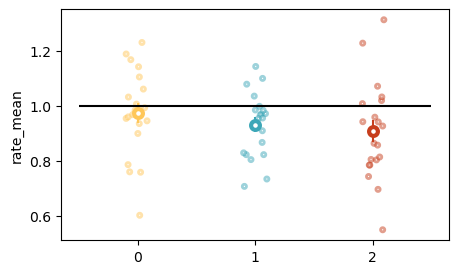

In [109]:
fig, axs = plt.subplots(1,1, figsize = (5,3))
r = 0
for test in sub_experiments:
    sns.stripplot(data = data[data.study == test],
                  x = r,
                  y = 'rate_mean',
                  hue = 'study',
                  ax = axs,
                  linewidth = 2,
                  s = 3,
                  edgecolor =  {'background': '#3DA7B8', 'target': '#C73E1D', 'target_polarity': '#FFC759'}[test],
                  palette = {'background': 'white', 'target': 'white', 'target_polarity': 'white'},
                  legend = False,
                  alpha = 0.5,
                 zorder = -2)
    
    axs.scatter(r, data[data.study == test]['rate_mean'].mean(),
                facecolor = {'background': 'white', 'target': 'white', 'target_polarity': 'white'}[test],
                edgecolor = {'background': '#3DA7B8', 'target': '#C73E1D', 'target_polarity': '#FFC759'}[test], 
                s = 40,
                linewidth = 3,
                zorder = 1)
    
    axs.vlines(r, 
               data[data.study == test]['rate_mean'].mean()-data[data.study == test]['rate_mean'].sem(),
               data[data.study == test]['rate_mean'].mean()+data[data.study == test]['rate_mean'].sem(),
               color = {'background': '#3DA7B8', 'target': '#C73E1D', 'target_polarity': '#FFC759'}[test], zorder = -1)
    
    r+=1

axs.hlines(1, -0.5, 2.5, color = 'black');
fig.savefig(f'{path}movement_rates_at_cluster_center.svg');